# Data inspection

In [15]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append("/home/johmathe/bgbench")
os.environ["PYTHONPATH"] = os.pathsep.join(sys.path)
from src.data import omics_datamodule


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Preparing dataset...


GPL10558.txt.gz: 100%|██████████| 60.8M/60.8M [00:03<00:00, 16.9MiB/s]


Successfully downloaded GPL10558
!Series_title	"Alzheimer, Mild Cognitive impairment and control samples from AddneuroMed Cohort"

!Series_geo_accession	"GSE63063"

!Series_status	"Public on Aug 05 2015"

!Series_submission_date	"Nov 06 2014"

!Series_last_update_date	"May 30 2024"

!Series_pubmed_id	"26343147"

!Series_summary	"This SuperSeries is composed of the SubSeries listed below."

!Series_overall_design	"Refer to individual Series"

!Series_type	"Expression profiling by array"

!Series_sample_id	"GSM1539080 GSM1539081 GSM1539082 GSM1539083 GSM1539084 GSM1539085 GSM1539086 GSM1539087 GSM1539088 GSM1539089 GSM1539090 GSM1539091 GSM1539092 GSM1539093 GSM1539094 GSM1539095 GSM1539096 GSM1539097 GSM1539098 GSM1539099 GSM1539100 GSM1539101 GSM1539102 GSM1539103 GSM1539104 GSM1539105 GSM1539106 GSM1539107 GSM1539108 GSM1539109 GSM1539110 GSM1539111 GSM1539112 GSM1539113 GSM1539114 GSM1539115 GSM1539116 GSM1539117 GSM1539118 GSM1539119 GSM1539120 GSM1539121 GSM1539122 GSM1539123 GSM15

GPL6947.txt.gz: 100%|██████████| 59.9M/59.9M [00:04<00:00, 13.6MiB/s]


Successfully downloaded GPL6947
!Series_title	"Alzheimer, Mild Cognitive impairment and control samples from AddneuroMed Cohort"

!Series_geo_accession	"GSE63063"

!Series_status	"Public on Aug 05 2015"

!Series_submission_date	"Nov 06 2014"

!Series_last_update_date	"May 30 2024"

!Series_pubmed_id	"26343147"

!Series_summary	"This SuperSeries is composed of the SubSeries listed below."

!Series_overall_design	"Refer to individual Series"

!Series_type	"Expression profiling by array"

!Series_sample_id	"GSM1539080 GSM1539081 GSM1539082 GSM1539083 GSM1539084 GSM1539085 GSM1539086 GSM1539087 GSM1539088 GSM1539089 GSM1539090 GSM1539091 GSM1539092 GSM1539093 GSM1539094 GSM1539095 GSM1539096 GSM1539097 GSM1539098 GSM1539099 GSM1539100 GSM1539101 GSM1539102 GSM1539103 GSM1539104 GSM1539105 GSM1539106 GSM1539107 GSM1539108 GSM1539109 GSM1539110 GSM1539111 GSM1539112 GSM1539113 GSM1539114 GSM1539115 GSM1539116 GSM1539117 GSM1539118 GSM1539119 GSM1539120 GSM1539121 GSM1539122 GSM1539123 GSM153

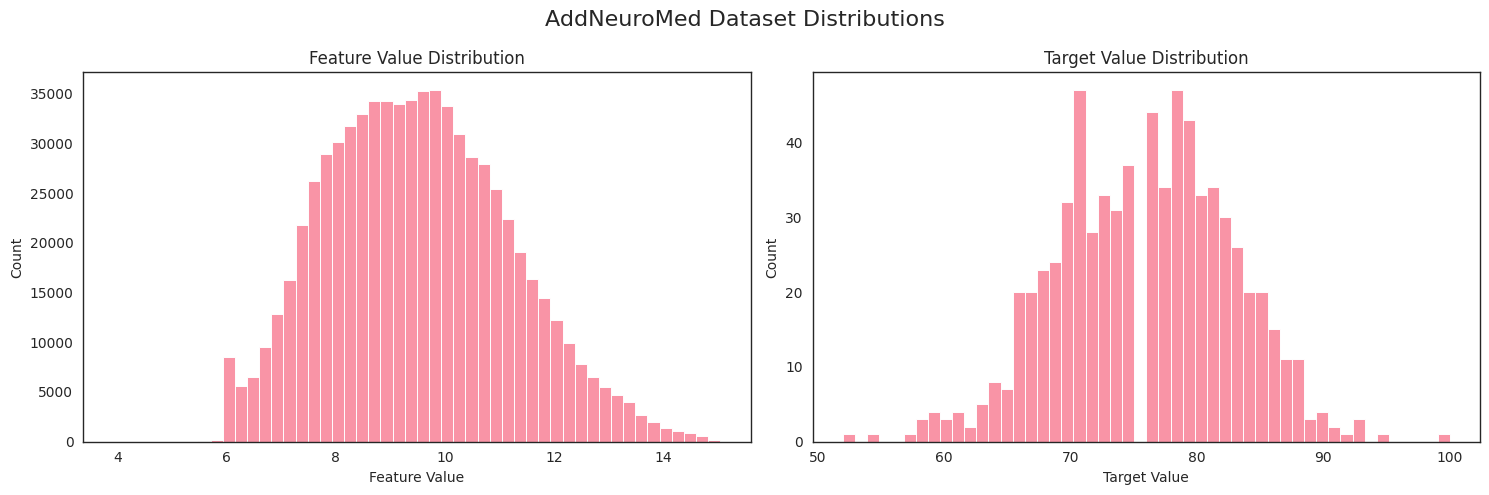


AddNeuroMed Dataset Statistics:
Number of samples: 717
Number of features: 1000

Target Statistics:
Mean: 75.82
Std: 6.82
Min: 52.00
Max: 100.00


In [17]:

# Set style
sns.set_palette("husl")

def plot_dataset_distributions(datamodule_class, title):
    """Plot feature and target distributions for a dataset."""
    # Initialize datamodule
    datamodule = datamodule_class()
    datamodule.prepare_data()
    
    # Load data
    selected_data = pd.read_parquet(datamodule.selected_data_path)
    targets = np.load(datamodule.targets_path)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{title} Dataset Distributions', fontsize=16)
    
    # Plot feature distributions
    sns.histplot(data=selected_data.values.flatten(), ax=ax1, bins=50)
    ax1.set_title('Feature Value Distribution')
    ax1.set_xlabel('Feature Value')
    ax1.set_ylabel('Count')
    
    # Plot target distribution
    sns.histplot(data=targets, ax=ax2, bins=50)
    ax2.set_title('Target Value Distribution')
    ax2.set_xlabel('Target Value')
    ax2.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    print(f"Number of samples: {len(targets)}")
    print(f"Number of features: {selected_data.shape[1]}")
    print(f"\nTarget Statistics:")
    print(f"Mean: {np.mean(targets):.2f}")
    print(f"Std: {np.std(targets):.2f}")
    print(f"Min: {np.min(targets):.2f}")
    print(f"Max: {np.max(targets):.2f}")

# Plot distributions for each dataset
plot_dataset_distributions(omics_datamodule.MortrPacDataModule, "MortrPac")
plot_dataset_distributions(omics_datamodule.PanCancerDataModule, "PanCancer")
plot_dataset_distributions(omics_datamodule.AddNeuroMedOmicsDataModule, "AddNeuroMed")